# Scattering Cross Section of a Finite Dielectric Cylinder



In [7]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

## create functions

In [1]:
def make_geometry(r, h, cthik, metal=True, n_cyl=2.0):
    """Return geometry list for cylinder."""
    if metal:
        material = mp.metal
    else:
        material = mp.Medium(index=n_cyl)

    geometry = [
        mp.Block(
            material=material,
            center=mp.Vector3(cthik * r),
            size=mp.Vector3(r, 0, h),
        )
    ]
    return geometry

In [5]:
def make_simulation(r, h, cthik, resolution=25, metal=False):
    """Build simulation object (without geometry if metal=False)."""
    wvl_min = 2 * np.pi * r / 10
    wvl_max = 2 * np.pi * r / 2
    frq_min = 1 / wvl_max
    frq_max = 1 / wvl_min
    frq_cen = 0.5 * (frq_min + frq_max)
    dfrq = frq_max - frq_min
    nfrq = 100

    dpml = cthik * wvl_max
    dair = 1.0 * wvl_max

    pml_layers = [mp.PML(thickness=dpml)]
    sr = r + dair + dpml
    sz = dpml + dair + h + dair + dpml
    cell_size = mp.Vector3(sr, 0, sz)

    # circularly polarized source
    sources = [
        mp.Source(
            mp.GaussianSource(frq_cen, fwidth=dfrq, is_integrated=True),
            component=mp.Er,
            center=mp.Vector3(cthik * sr, 0, -0.5 * sz + dpml),
            size=mp.Vector3(sr),
        ),
        mp.Source(
            mp.GaussianSource(frq_cen, fwidth=dfrq, is_integrated=True),
            component=mp.Ep,
            center=mp.Vector3(cthik * sr, 0, -0.5 * sz + dpml),
            size=mp.Vector3(sr),
            amplitude=-1j,
        ),
    ]

    geometry = make_geometry(r, h, cthik, metal=metal) if metal else None

    sim = mp.Simulation(
        cell_size=cell_size,
        geometry=geometry,
        boundary_layers=pml_layers,
        resolution=resolution,
        sources=sources,
        dimensions=mp.CYLINDRICAL,
        m=-1,
    )

    return sim, frq_cen, dfrq, nfrq


In [3]:
def plot_ring_schematic(r, w, sr, height=1):
    """
    Plot both a 2D polar (top-down) and longitudinal cross-section view
    of the ring resonator.
    
    r      : inner radius of ring
    w      : width of the ring
    sr     : outer boundary of computational cell
    height : arbitrary vertical thickness for schematic
    """
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # --- Polar (top-down) view ---
    theta = np.linspace(0, 2*np.pi, 500)
    axs[0] = plt.subplot(1, 2, 1, projection='polar')
    axs[0].set_theta_zero_location("N")
    axs[0].set_theta_direction(-1)
    axs[0].fill_between(theta, r, r + w, color='grey', alpha=0.7, label='Ring waveguide')
    axs[0].plot(theta, sr*np.ones_like(theta), 'k--', label='Computational boundary')
    axs[0].set_rmax(sr + 1)
    axs[0].set_rticks([0, r, r + w, sr])
    axs[0].set_rlabel_position(-22.5)
    axs[0].set_title("Top-down (polar) view")
    axs[0].legend(loc='upper right')

    # --- Longitudinal (cross-section) view ---
    axs[1].set_aspect('equal')
    axs[1].set_xlim(0, sr + 5)
    axs[1].set_ylim(0, height + 0.5)
    axs[1].add_patch(plt.Rectangle((r, 0), w, height, color='grey', alpha=0.7))
    axs[1].axvline(sr, color='k', linestyle='--', label='Computational boundary')
    axs[1].set_xlabel("Radius r")
    axs[1].set_ylabel("Height z")
    axs[1].set_title("Longitudinal cross-section")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

## Make simulation 

Make simulation and show the geometry of simaltion object

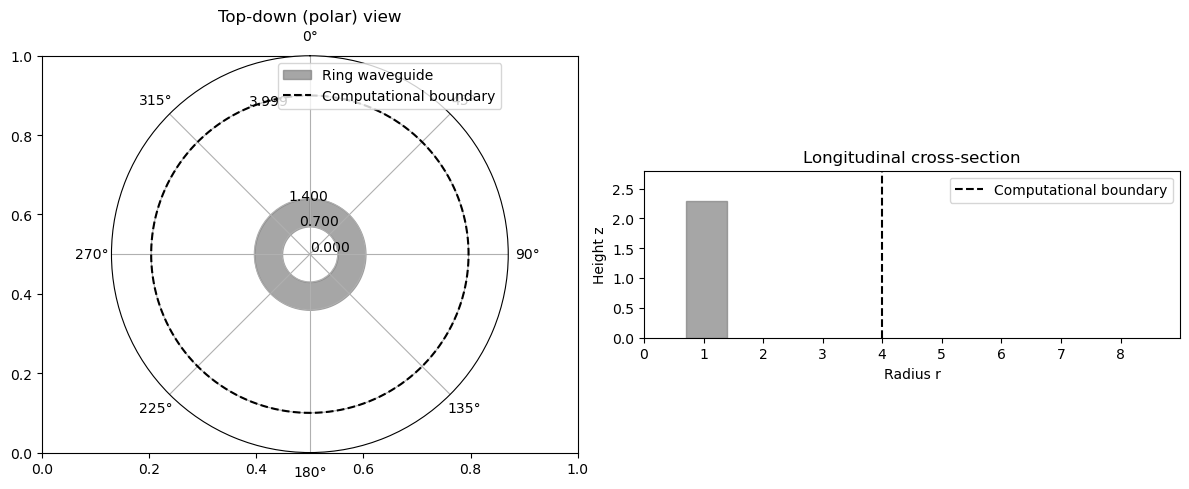

In [23]:
r, h, cthik = .7, 2.3, 0.5
sim, frq_cen, dfrq, nfrq = make_simulation(r, h, cthik, metal=True)

w=r
wvl_min = 2 * np.pi * r / 10
wvl_max = 2 * np.pi * r / 2
frq_min = 1 / wvl_max
frq_max = 1 / wvl_min
frq_cen = 0.5 * (frq_min + frq_max)
dfrq = frq_max - frq_min
nfrq = 100

dpml = cthik * wvl_max
dair = 1.0 * wvl_max


sr = r + dair + dpml
plot_ring_schematic(r, w, sr, height=h)



## Add flux monitors

In [24]:
def add_flux_monitors(sim, r, h, cthik, frq_cen, dfrq, nfrq):
    """Attach flux regions and return handles."""
    box_z1 = sim.add_flux(
        frq_cen, dfrq, nfrq,
        mp.FluxRegion(center=mp.Vector3(cthik * r, 0, -0.5 * h), size=mp.Vector3(r))
    )
    box_z2 = sim.add_flux(
        frq_cen, dfrq, nfrq,
        mp.FluxRegion(center=mp.Vector3(cthik * r, 0, +0.5 * h), size=mp.Vector3(r))
    )
    box_r = sim.add_flux(
        frq_cen, dfrq, nfrq,
        mp.FluxRegion(center=mp.Vector3(r), size=mp.Vector3(z=h))
    )
    return box_z1, box_z2, box_r

## Monitors

In [25]:
def run_reference(r, h, cthik):
    """Run reference simulation without scatterer and return flux data."""
    sim, frq_cen, dfrq, nfrq = make_simulation(r, h, cthik, metal=False)
    box_z1, box_z2, box_r = add_flux_monitors(sim, r, h, cthik, frq_cen, dfrq, nfrq)

    sim.run(until_after_sources=10)
    freqs = mp.get_flux_freqs(box_z1)
    box_z1_data = sim.get_flux_data(box_z1)
    box_z2_data = sim.get_flux_data(box_z2)
    box_r_data = sim.get_flux_data(box_r)
    box_z1_flux0 = mp.get_fluxes(box_z1)

    return freqs, box_z1_data, box_z2_data, box_r_data, box_z1_flux0

In [26]:
def run_scatterer(r, h, cthik, box_z1_data, box_z2_data, box_r_data, metal=True):
    """Run scatterer simulation (metal or dielectric) and return fluxes."""
    sim, frq_cen, dfrq, nfrq = make_simulation(r, h, cthik, metal=metal)
    box_z1, box_z2, box_r = add_flux_monitors(sim, r, h, cthik, frq_cen, dfrq, nfrq)

    # load reference fields
    sim.load_minus_flux_data(box_z1, box_z1_data)
    sim.load_minus_flux_data(box_z2, box_z2_data)
    sim.load_minus_flux_data(box_r, box_r_data)

    sim.run(until_after_sources=100)

    return mp.get_fluxes(box_z1), mp.get_fluxes(box_z2), mp.get_fluxes(box_r)

In [27]:
def analyze_fluxes(freqs, refl0, refl, tran, side, r):
    """Compute scattering cross-section and R/T/A coefficients."""
    scatt_flux = np.asarray(refl) - np.asarray(tran) - np.asarray(side)
    intensity = np.asarray(refl0) / (np.pi * r**2)
    scatt_cs = np.divide(-scatt_flux, intensity)

    R = np.asarray(refl) / np.asarray(refl0)
    T = np.asarray(tran) / np.asarray(refl0)
    A = 1 - R - T  # absorption

    return scatt_cs, R, T, A

In [37]:
import matplotlib.animation as animation


def run_with_animation(r, h, cthik, metal=True, field_component=mp.Ez,
                       frames=40, until=200, resolution=25):
    """Run simulation and animate the chosen field component."""
    sim, frq_cen, dfrq, nfrq = make_simulation(r, h, cthik, resolution=resolution, metal=metal)

    # Set up figure
    fig, ax = plt.subplots()
    ax.set_title(f"Field evolution: {field_component}")
    ax.set_xlabel("r (a.u.)")
    ax.set_ylabel("z (a.u.)")

    # initialize plot data
    field_data = sim.get_array(component=field_component, center=mp.Vector3(), size=sim.cell_size)
    im = ax.imshow(np.rot90(field_data),
                   interpolation='spline36', cmap='RdBu',
                   extent=[-0.5*sim.cell_size.x, 0.5*sim.cell_size.x,
                           -0.5*sim.cell_size.z, 0.5*sim.cell_size.z])

    plt.colorbar(im, ax=ax)

    def update(frame):
        sim.run(until=frame * until / frames)
        field_data = sim.get_array(component=field_component,
                                   center=mp.Vector3(),
                                   size=sim.cell_size)
        im.set_array(np.rot90(field_data))
        return [im]

    ani = animation.FuncAnimation(fig, update, frames=frames, blit=False, repeat=False)
    plt.show()
    # optionally save:
    # ani.save("fields.mp4", fps=10, dpi=150)

    return ani


### Plot functions

In [28]:
def plot_scattering(freqs, scatt_cs):
    plt.figure()
    plt.plot(freqs, scatt_cs, label="Scattering σ")
    plt.xlabel("Frequency")
    plt.ylabel("σ_scat")
    plt.legend()
    plt.grid(True)

In [29]:
def plot_rta(freqs, R, T, A):
    plt.figure()
    plt.plot(freqs, R, label="Reflection")
    plt.plot(freqs, T, label="Transmission")
    plt.plot(freqs, A, label="Absorption")
    plt.xlabel("Frequency")
    plt.ylabel("Coefficient")
    plt.legend()
    plt.grid(True)

## Simulate

In [39]:
r, h, cthik = .7, 2.3, 0.5
# reference run
freqs, box_z1_data, box_z2_data, box_r_data, refl0 = run_reference(r, h, cthik)

# scatterer run (metal)
refl, tran, side = run_scatterer(r, h, cthik, box_z1_data, box_z2_data, box_r_data, metal=True)

-----------
Initializing structure...
time for choose_chunkdivision = 0.000418901 s
Working in Cylindrical dimensions.
Computational cell is 4 x 0 x 8.88 with resolution 25
time for set_epsilon = 0.0132201 s
-----------
Meep: using complex fields.


FloatProgress(value=0.0, description='0% done ', max=15.49778699874878)

run 0 finished at t = 15.5 (775 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 5.50747e-05 s
Working in Cylindrical dimensions.
Computational cell is 4 x 0 x 8.88 with resolution 25
     block, center = (0.35,0,0)
          size (0.7,0,2.3)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
time for set_epsilon = 0.00925803 s
-----------
Meep: using complex fields.


FloatProgress(value=0.0, description='0% done ', max=105.49778699874878)

run 0 finished at t = 105.5 (5275 timesteps)


### Show graphics

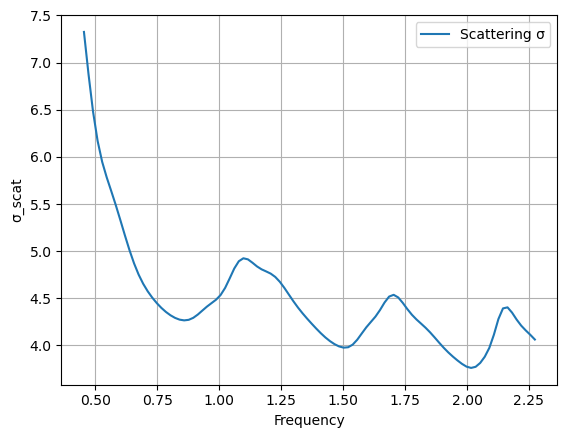

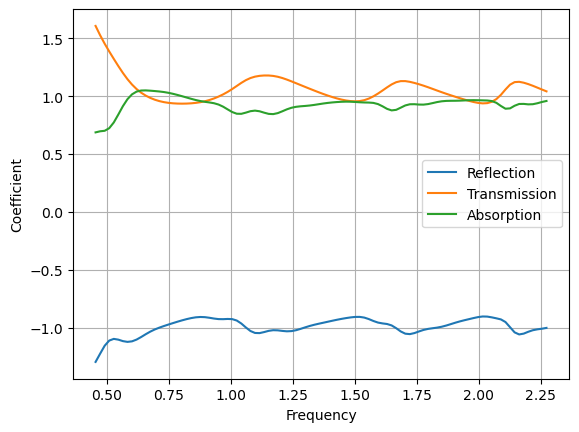

In [41]:
# analysis
scatt_cs, R, T, A = analyze_fluxes(freqs, refl0, refl, tran, side, r)

# plots
plot_scattering(freqs, scatt_cs)
plot_rta(freqs, R, T, A)

# animation
#run_with_animation(r, h, cthik, metal=True, field_component=mp.Ez)

plt.show()

### Verify with previous 

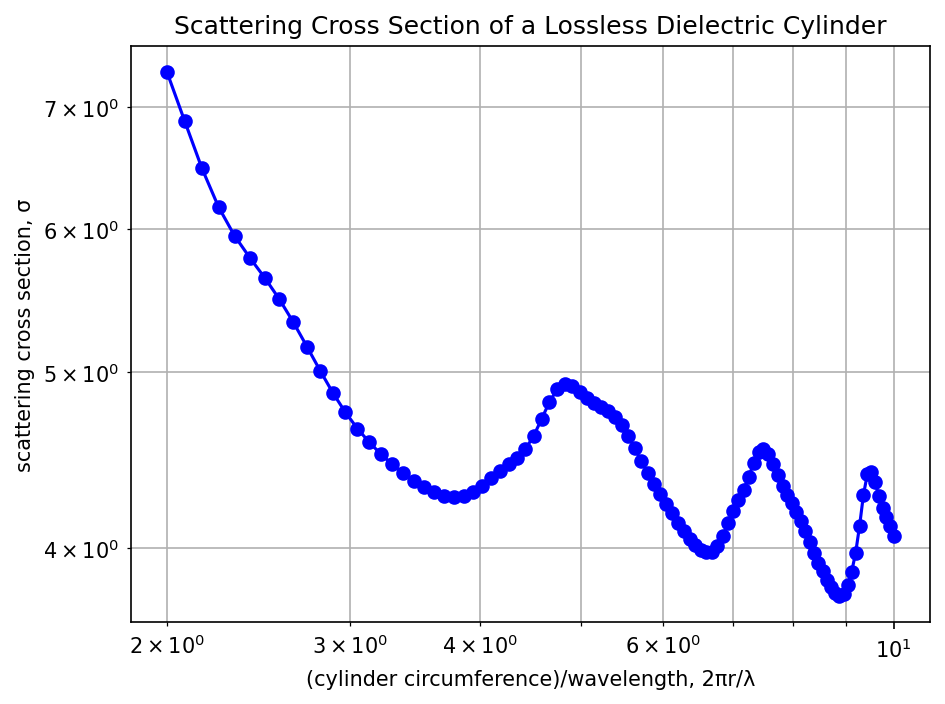

In [42]:
plt.figure(dpi=150)
plt.loglog(2 * np.pi * r * np.asarray(freqs), scatt_cs, "bo-")
plt.grid(True, which="both", ls="-")
plt.xlabel("(cylinder circumference)/wavelength, 2πr/λ")
plt.ylabel("scattering cross section, σ")
plt.title("Scattering Cross Section of a Lossless Dielectric Cylinder")
plt.tight_layout()
plt.savefig("cylinder_cross_section.png")